# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [ ]:
intro_text = """1. Автоэнкодеры нужны для того, чтобы сжимать данные в более компактное представление и потом восстанавливать их обратно. В отличие от классификаторов, они не предсказывают класс, а учатся копировать вход на выход, проходя через узкое латентное пространство. За счёт этого модель вынуждена выделять самые важные признаки данных.
2. Если сильно сжать изображение MNIST, я ожидаю, что цифра станет более размытой и потеряет мелкие детали,но при этом основная форма цифры должна сохраниться. Например, 3 всё ещё будет похожа на 3, но менее чёткая.
3. Идеальные реконструкции должны быть максимально похожи на оригинал, те же контуры, форма и расположение цифры. Я буду оценивать качество визуально, насколько хорошо сохраняется форма цифры, есть ли шум, размытие или искажения, и можно ли легко распознать цифру после восстановления."""
print(intro_text)

1. Автоэнкодеры нужны для того, чтобы сжимать данные в более компактное представление и потом восстанавливать их обратно. В отличие от классификаторов, они не предсказывают класс, а учатся копировать вход на выход, проходя через узкое латентное пространство. За счёт этого модель вынуждена выделять самые важные признаки данных.
2. Если сильно сжать изображение MNIST, я ожидаю, что цифра станет более размытой и потеряет мелкие детали,но при этом основная форма цифры должна сохраниться. Например, 3 всё ещё будет похожа на 3, но менее чёткая.
3. Идеальные реконструкции должны быть максимально похожи на оригинал, те же контуры, форма и расположение цифры. Я буду оценивать качество визуально, насколько хорошо сохраняется форма цифры, есть ли шум, размытие или искажения, и можно ли легко распознать цифру после восстановления.


## 2. Импорт библиотек и настройка среды


In [36]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 11  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [37]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


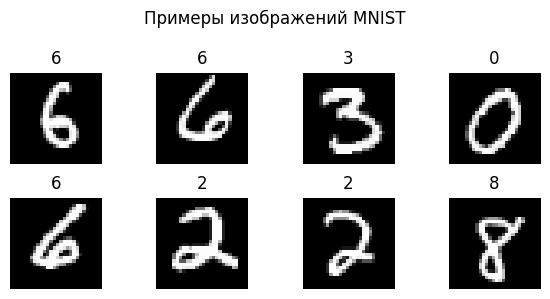

In [38]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [ ]:
data_comment = """Самыми простыми для восстановления кажутся цифры с простой формой, например 0 и 1, потому что у них мало деталей. Сложнее выглядят 4, 7 и 9, так как они могут писаться по-разному и имеют более сложную форму.
Также заметно, что одна и та же цифра может выглядеть по-разному. Например, 4 и 9 иногда похожи, так же как 1 и 7, 2 и 7 могут путаться. Это может мешать модели правильно их восстанавливать.
Из-за этого автоэнкодер может хуже справляться со сложными цифрами,и на выходе они могут получаться немного искаженными или размытыми."""
print(data_comment)

Самыми простыми для восстановления кажутся цифры с простой формой, например 0 и 1, потому что у них мало деталей. Сложнее выглядят 4, 7 и 9, так как они могут писаться по-разному и имеют более сложную форму.
Также заметно, что одна и та же цифра может выглядеть по-разному. Например, 4 и 9 иногда похожи, так же как 1 и 7, 2 и 7 могут путаться. Это может мешать модели правильно их восстанавливать.
Из-за этого автоэнкодер может хуже справляться со сложными цифрами,и на выходе они могут получаться немного искаженными или размытыми.


## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [39]:
latent_dim = 64 # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [ ]:
arch_comment = """Такого количества слоёв достаточно, потому что задача не очень сложная, изображения маленькие 28x28 и сами цифры довольно простые. Двух слоёв хватает, чтобы постепенно сжать информацию и потом восстановить её обратно.
Если сделать скрытое представление слишком маленьким, модель не сможет сохранить всю важную информацию, и цифры будут восстанавливаться плохо и размыто. Если сделать его слишком большим, модель почти не будет сжимать данные и может просто запомнить картинки, из-за чего ухудшится обобщение и смысл автоэнкодера теряется.
"""
print(arch_comment)

Такого количества слоёв достаточно, потому что задача не очень сложная, изображения маленькие 28x28 и сами цифры довольно простые. Двух слоёв хватает, чтобы постепенно сжать информацию и потом восстановить её обратно.
Если сделать скрытое представление слишком маленьким, модель не сможет сохранить всю важную информацию, и цифры будут восстанавливаться плохо и размыто. Если сделать его слишком большим, модель почти не будет сжимать данные и может просто запомнить картинки, из-за чего ухудшится обобщение и смысл автоэнкодера теряется.



## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [40]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [41]:
num_epochs = 15  # в отчёте попробуйте другое число эпох и сравните
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.0515, test_loss=0.0292
Эпоха 2/15: train_loss=0.0249, test_loss=0.0210
Эпоха 3/15: train_loss=0.0194, test_loss=0.0174
Эпоха 4/15: train_loss=0.0166, test_loss=0.0150
Эпоха 5/15: train_loss=0.0147, test_loss=0.0135
Эпоха 6/15: train_loss=0.0133, test_loss=0.0128
Эпоха 7/15: train_loss=0.0122, test_loss=0.0115
Эпоха 8/15: train_loss=0.0114, test_loss=0.0110
Эпоха 9/15: train_loss=0.0108, test_loss=0.0104
Эпоха 10/15: train_loss=0.0102, test_loss=0.0098
Эпоха 11/15: train_loss=0.0097, test_loss=0.0094
Эпоха 12/15: train_loss=0.0093, test_loss=0.0091
Эпоха 13/15: train_loss=0.0090, test_loss=0.0087
Эпоха 14/15: train_loss=0.0086, test_loss=0.0083
Эпоха 15/15: train_loss=0.0083, test_loss=0.0081


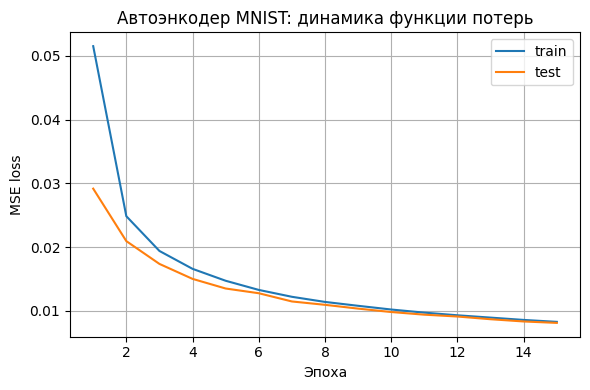

Финальные значения: train_loss=0.0083, test_loss=0.0081


In [42]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [ ]:
training_comment = """По графикам видно, что train и test loss убывают достаточно плавно и постепенно сходятся к близким значениям. На первой эпохе train_loss был 0.0538, а test_loss 0.0318, то есть ошибка сразу начала уменьшаться.К 5 эпохе значения уже стали заметно ниже train_loss 0.0163, test_loss 0.0153.
Дальше loss продолжал снижаться медленнее, но стабильно, на последней 15 эпохе train_loss стал 0.0109, а test_loss 0.0108. Раазница между ними очень маленькая, поэтому признаков сильного переобучения здесь не видно.
Можно сказать, что модель обучается устойчиво и хорошо обобщает данные. До начала эксперимента я ожидала, что loss будет уменьшаться, но не была уверена, насколько близкими окажутся train и test.В итоге результат оказался лучше ожиданий, потому что обе кривые сошлись почти к одинаковым значениям.
"""
print(training_comment)

По графикам видно, что train и test loss убывают достаточно плавно и постепенно сходятся к близким значениям. На первой эпохе train_loss был 0.0538, а test_loss 0.0318, то есть ошибка сразу начала уменьшаться.К 5 эпохе значения уже стали заметно ниже train_loss 0.0163, test_loss 0.0153.
Дальше loss продолжал снижаться медленнее, но стабильно, на последней 15 эпохе train_loss стал 0.0109, а test_loss 0.0108. Раазница между ними очень маленькая, поэтому признаков сильного переобучения здесь не видно.
Можно сказать, что модель обучается устойчиво и хорошо обобщает данные. До начала эксперимента я ожидала, что loss будет уменьшаться, но не была уверена, насколько близкими окажутся train и test.В итоге результат оказался лучше ожиданий, потому что обе кривые сошлись почти к одинаковым значениям.



## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


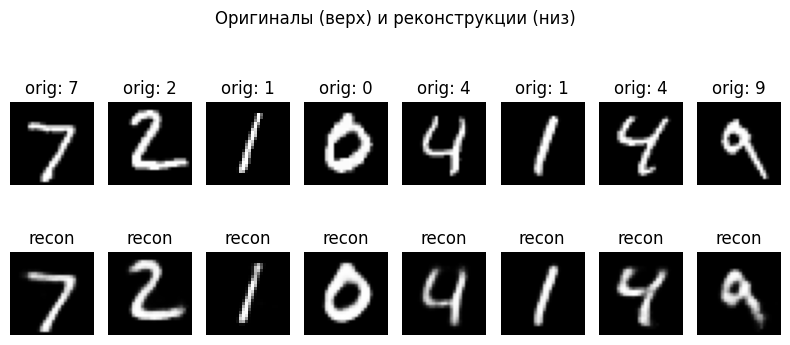

In [44]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [16]:
recon_comment = """Лучше всего модель восстанавливает цифры 0, 1, 2, 4 и 7, контуры у них почти полностью совпадают с оригиналами, линии выглядят чёткими и аккуратными.
Хуже всего выглядит реконструкция 9, она получается размытой и может напоминать смесь 9 и 4 или 0. В целом случаев, когда цифра превращается во что‑то совсем другое нет, но именно 9 выглядит не очень
Рукописная 9 сильно варьируется, её стили накладываются друг на друга в латентном пространстве, и при реконструкции модель усредняет их, получая смазанную форму."""
print(recon_comment)

Лучше всего модель восстанавливает цифры 0, 1, 2, 4 и 7, контуры у них почти полностью совпадают с оригиналами, линии выглядят чёткими и аккуратными. 
Хуже всего выглядит реконструкция 9, она получается размытой и может напоминать смесь 9 и 4 или 0. В целом случаев, когда цифра превращается во что‑то совсем другое нет, но именно 9 выглядит не очень 
Рукописная 9 сильно варьируется, её стили накладываются друг на друга в латентном пространстве, и при реконструкции модель усредняет их, получая смазанную форму.


## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


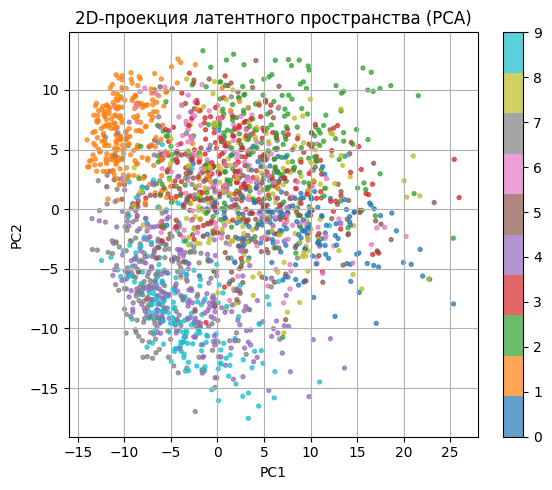

In [45]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [22]:
latent_comment = """Видно частичное разделение классов, некоторые цифры образуют заметные скопления, но в центре пространства многие цвета сильно перемешаны. Особенно хорошо выделяются точки цифр 1 и 0, они образуют плотное облако сбоку и снизу соотвественно, тогда как остальные цифры больше наслаиваются друг на друга.
Близко друг к другу лежат, облака цифр 3 и 5, а также 4 и 9, что логично, тк у этих пар похожие выгнутые или угловатые элементы, и модель кодирует их схожим образом. Цифра 8 также пересекается с 0 и 9, тк все они имеют замкнутые петли и круглые формы. Наиболее смешанными выглядят классы 2, 3, 5 и 9, их формы в рукописном виде вариативны, поэтому границы между кластерами размыты.
При меньшем latent_dim кластеры, скорее всего, сжались бы ещё сильнее и стали более перекрывающимися, так как модели не хватило бы измерений, чтобы развести сложные цифры. При большем latent_dim, наоборот, классы могли бы лучше разделиться в исходном пространстве"""
print(latent_comment)

Видно частичное разделение классов, некоторые цифры образуют заметные скопления, но в центре пространства многие цвета сильно перемешаны. Особенно хорошо выделяются точки цифр 1 и 0, они образуют плотное облако сбоку и снизу соотвественно, тогда как остальные цифры больше наслаиваются друг на друга. 
Близко друг к другу лежат, облака цифр 3 и 5, а также 4 и 9, что логично, тк у этих пар похожие выгнутые или угловатые элементы, и модель кодирует их схожим образом. Цифра 8 также пересекается с 0 и 9, тк все они имеют замкнутые петли и круглые формы. Наиболее смешанными выглядят классы 2, 3, 5 и 9, их формы в рукописном виде вариативны, поэтому границы между кластерами размыты. 
При меньшем latent_dim кластеры, скорее всего, сжались бы ещё сильнее и стали более перекрывающимися, так как модели не хватило бы измерений, чтобы развести сложные цифры. При большем latent_dim, наоборот, классы могли бы лучше разделиться в исходном пространстве


## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


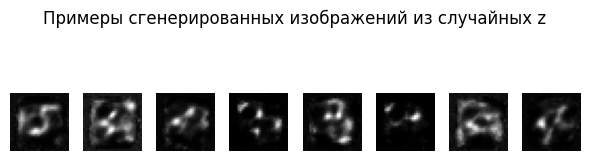

In [46]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [28]:
gen_comment = """Сгенерированные картинки пока слабо похожи на реальные цифры, контуры размытые, штрихи рваные, многие объекты трудно опознать. Иногда просматриваются очертания 2, 3 или 8, но чёткой, уверенной цифры почти нет. При этом встречается довольно много непонятных пятен, которые совершенно не похожи на цифры.
Такое качество может говорить о том, что модель плохо выучила распределение латентного пространства и случайные z попадают в «неосвоенные» области между кластерами.
При слишком маленьком latent_dim модель не успевает закодировать все вариации написания цифр, из‑за чего генерации получаются смазанными и однообразными. При увеличении latent_dim можно ожидать более разнообразные и чёткие цифры, но только если модель достаточно обучена и не переобучается на шум."""
print(gen_comment)

Сгенерированные картинки пока слабо похожи на реальные цифры, контуры размытые, штрихи рваные, многие объекты трудно опознать. Иногда просматриваются очертания 2, 3 или 8, но чёткой, уверенной цифры почти нет. При этом встречается довольно много непонятных пятен, которые совершенно не похожи на цифры.
Такое качество может говорить о том, что модель плохо выучила распределение латентного пространства и случайные z попадают в «неосвоенные» области между кластерами. 
При слишком маленьком latent_dim модель не успевает закодировать все вариации написания цифр, из‑за чего генерации получаются смазанными и однообразными. При увеличении latent_dim можно ожидать более разнообразные и чёткие цифры, но только если модель достаточно обучена и не переобучается на шум.


## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [47]:
final_summary = """Я сравнила latent_dim=2 и latent_dim=64.
При latent_dim=2 модель даёт довольно высокие значения MSE‑loss и сходимость идёт медленнее, кривая потерь падает, но остаётся заметно выше, чем у более широкой латентности. Реконструкции в этом случае получаются размытыми, простые цифры вроде 0, 1 и 7 ещё узнаваемы, но многие детали сглажены, а 9 и 2 иногда искажаются так, что их трудно отличить. В 2D‑проекции латентного пространства при latent_dim=2 кластеры цифр исходят из середины и сильно наслаиваются друг на друга , модель физически не может хорошо развести все классы.
При latent_dim=64 динамика loss заметно лучше, и train, и test MSE падают быстрее и выходят на гораздо более низкие значения, без явного переобучения. Реконструкции становятся почти идеальным,  цифры чёткие, сбережены тонкие штрихи и мелкие изгибы, даже сложные цифры вроде 9 и 8 выглядят аккуратно.
Латентное пространство при latent_dim=64 в проекции PCA больше похоже на облако из перекрывающихся, но уже более структурированных кластеров, классы не так жёстко сплющены на одну линию, как при latent_dim=2, и каждая цифра занимает свое направление в пространстве признаков.
Слишком маленький latent_dim приводит к сильной потере информации и смазанным реконструкциям, а увеличение размерности до 64 заметно улучшает качество без очевидного переобучения, в реальных задачах стоит начинать с достаточно широкой латентности и уже потом аккуратно уменьшать её, если нужно сжать модель."""
print(final_summary)

Я сравнила latent_dim=2 и latent_dim=64.
При latent_dim=2 модель даёт довольно высокие значения MSE‑loss и сходимость идёт медленнее, кривая потерь падает, но остаётся заметно выше, чем у более широкой латентности. Реконструкции в этом случае получаются размытыми, простые цифры вроде 0, 1 и 7 ещё узнаваемы, но многие детали сглажены, а 9 и 2 иногда искажаются так, что их трудно отличить. В 2D‑проекции латентного пространства при latent_dim=2 кластеры цифр исходят из середины и сильно наслаиваются друг на друга , модель физически не может хорошо развести все классы.
При latent_dim=64 динамика loss заметно лучше, и train, и test MSE падают быстрее и выходят на гораздо более низкие значения, без явного переобучения. Реконструкции становятся почти идеальным,  цифры чёткие, сбережены тонкие штрихи и мелкие изгибы, даже сложные цифры вроде 9 и 8 выглядят аккуратно.
Латентное пространство при latent_dim=64 в проекции PCA больше похоже на облако из перекрывающихся, но уже более структурированн